In [1]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from nvitk.pipes.qvtpy import config as qcfg

# Scalar stage-6 metrics (exclude per-timepoint columns)
DEFAULT_MEASUREMENTS = (
    "loc_mean_flow_ml_s",
    "loc_mean_velocity_mm_s",
    "loc_pi",
    "loc_ri",
    "loc_cross_section_area_mm2",
)

# Optional: stable vessel order (arterial then venous)
from nvitk.pipes.qvtpy.labels import QVTPY_CENTERLINE_AND_SEG_LABEL_BY_ID

DEFAULT_VESSEL_ORDER = list(QVTPY_CENTERLINE_AND_SEG_LABEL_BY_ID.values())


def load_qvtpy_measurements(
    *,
    csv_path: Path | None = None,
    output_root: Path | None = None,
    subjects: list[str] | None = None,
) -> pd.DataFrame:
    """Load stage-6 loc_measurements.csv from one file or many subjects."""
    if csv_path is not None:
        df = pd.read_csv(csv_path)
        if "subject" not in df.columns:
            df["subject"] = csv_path.parents[2].name  # .../<subject>/qvtpy/stage6_measure/...
        return df

    if output_root is None:
        raise ValueError("Provide csv_path or output_root")

    rows: list[pd.DataFrame] = []
    root = Path(output_root)
    subj_dirs = [root / s for s in subjects] if subjects else sorted(p for p in root.iterdir() if p.is_dir())

    for subj_dir in subj_dirs:
        meas = subj_dir / qcfg.QVT_SUBDIR / qcfg.STAGE6_MEASURE_DIR / "loc_measurements.csv"
        if not meas.is_file():
            continue
        part = pd.read_csv(meas)
        part["subject"] = subj_dir.name
        rows.append(part)

    if not rows:
        raise FileNotFoundError("No loc_measurements.csv found under output_root")

    return pd.concat(rows, ignore_index=True)


def plot_qvtpy_measurement_violins(
    df: pd.DataFrame,
    *,
    measurements: tuple[str, ...] = DEFAULT_MEASUREMENTS,
    label_col: str = "vessel_name",
    vessel_order: list[str] | None = DEFAULT_VESSEL_ORDER,
    hue_col: str | None = "subject",  # set None to hide subject color
    figsize_per_panel: tuple[float, float] = (4.5, 4.0),
    save_path: Path | None = None,
) -> plt.Figure:
    """
    Violin + scatter plots of qvtpy measurements, one panel per metric,
    x-axis = vessel label.
    """
    available = [m for m in measurements if m in df.columns]
    if not available:
        raise ValueError(f"None of {measurements} found in dataframe")

    long = df.melt(
        id_vars=[c for c in df.columns if c not in available],
        value_vars=available,
        var_name="measurement",
        value_name="value",
    ).dropna(subset=["value"])

    long[label_col] = long[label_col].astype(str)

    if vessel_order is not None:
        present = [v for v in vessel_order if v in long[label_col].unique()]
        extra = sorted(set(long[label_col]) - set(present))
        order = present + extra
    else:
        order = sorted(long[label_col].unique())

    n = len(available)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
    )

    for ax, meas in zip(axes.ravel(), available):
        sub = long[long["measurement"] == meas]
        sns.violinplot(
            data=sub,
            x=label_col,
            y="value",
            order=order,
            inner=None,
            cut=0,
            linewidth=0.8,
            ax=ax,
        )
        strip_kw = dict(
            data=sub,
            x=label_col,
            y="value",
            order=order,
            dodge=bool(hue_col),
            jitter=0.25,
            size=3,
            alpha=0.75,
            ax=ax,
        )
        if hue_col and hue_col in sub.columns:
            sns.stripplot(**strip_kw, hue=hue_col, legend=False)
        else:
            sns.stripplot(**strip_kw, color="0.15")

        ax.set_title(meas.replace("loc_", "").replace("_", " "))
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45)

    for ax in axes.ravel()[len(available):]:
        ax.set_visible(False)

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig



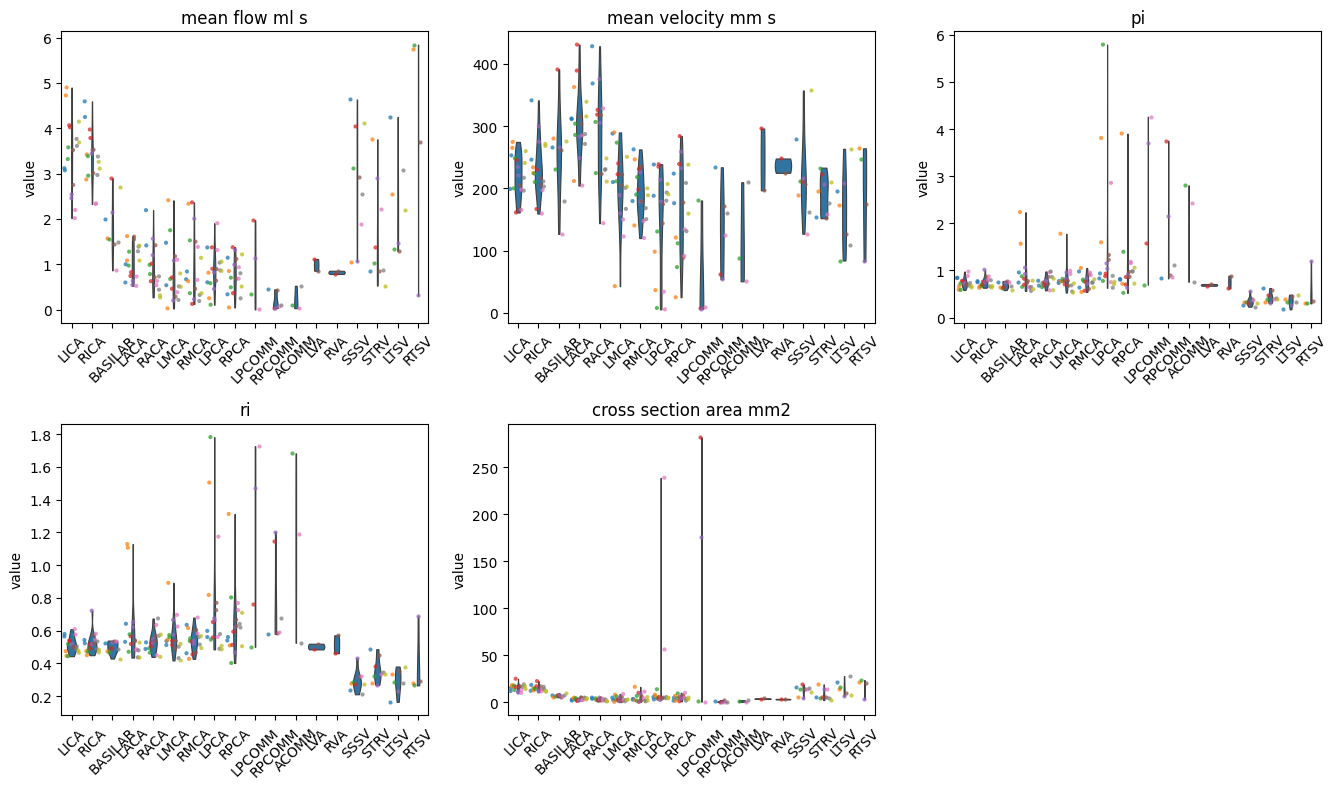

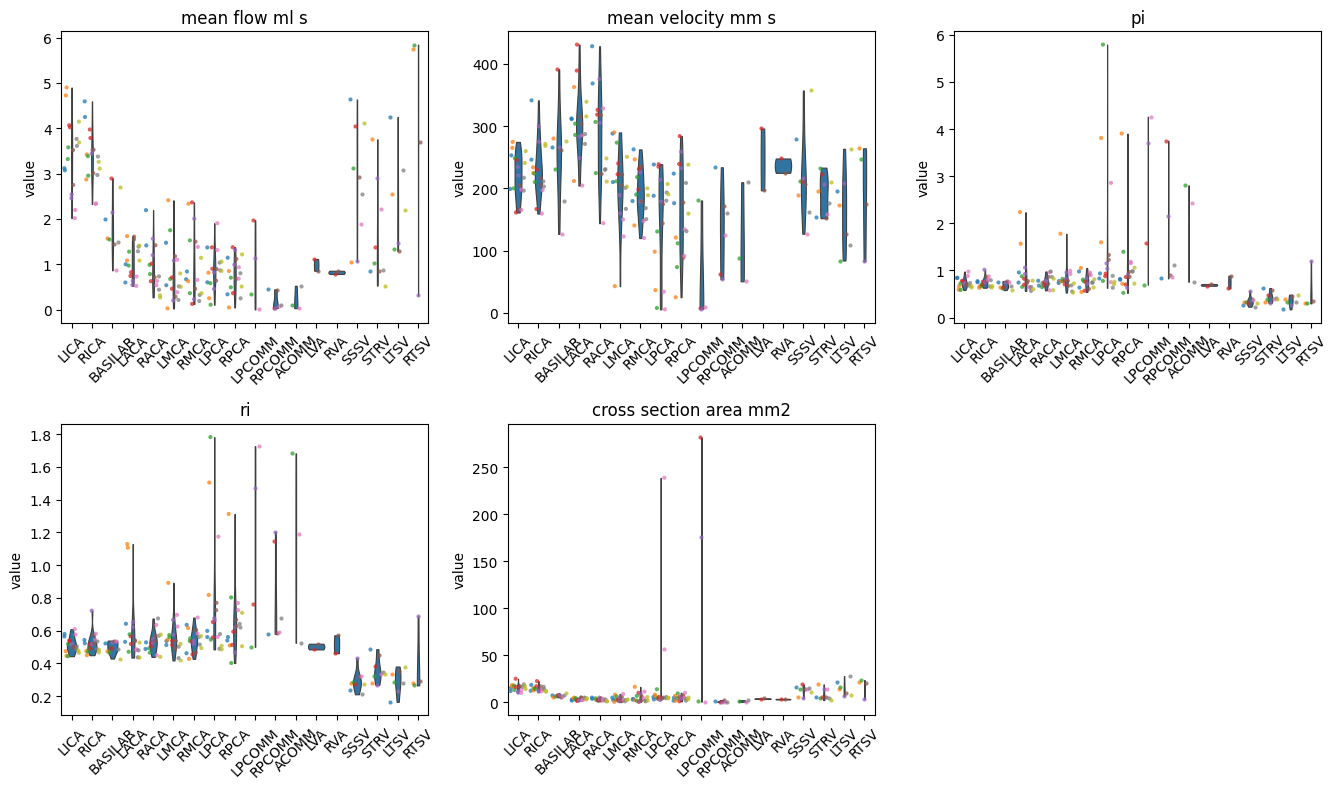

In [3]:


# --- usage examples ---
# Single subject:
# df = load_qvtpy_measurements(csv_path=Path(".../SUBJ/qvtpy/stage6_measure/loc_measurements.csv"))
# plot_qvtpy_measurement_violins(df, hue_col=None)

# Cohort:
df = load_qvtpy_measurements(output_root=Path("/home/imarcoss/DATA/LabVF/res_QVTPy"))
plot_qvtpy_measurement_violins(df, save_path=Path("qvtpy_violins.png"))